In [ ]:
"""
### 1. Setup & Utilities
**Aim:** Initialize environment, load API keys, and define core utility functions.
"""

import os
import json
import re
import string
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv, find_dotenv
from deepeval.metrics import GEval, AnswerRelevancyMetric
from deepeval.test_case import LLMTestCase, LLMTestCaseParams

# --- ENVIRONMENT ---
def setup_environment():
    load_dotenv(find_dotenv()) 
    if "OPENAI_API_KEY" not in os.environ:
        print("⚠️ WARNING: OPENAI_API_KEY not found. Metrics will fail.")
    else:
        print("✅ Environment loaded.")

# --- DATA CLEANING ---
def clean_id(col):
    """Robust cleaning for IDs/Phone Numbers."""
    return col.astype(str).str.replace(r'\.0$', '', regex=True).str.strip()


def preprocess_text(text):
    """Normalizes text (lowercase, remove emojis, strip spaces)."""
    if not isinstance(text, str): text = str(text)
    text = text.lower()
    emoji_pattern = re.compile("[" "\U0001f600-\U0001f64f" "\U0001f300-\U0001f5ff" "\U0001f680-\U0001f6ff" "\U0001f1e0-\U0001f1ff" "\U00002702-\U000027b0" "\U000024c2-\U0001f251" "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r"", text).strip()
    return re.sub(r"\s+", " ", text)

# --- LOADING RESOURCES ---
def load_flow_definitions(json_dir):
    definitions = {}
    path = Path(json_dir)
    if not path.exists(): return definitions
    for jf in path.glob("*.json"):
        try:
            with jf.open("r", encoding="utf-8") as f:
                data = json.load(f)
                if isinstance(data, dict):
                    for k, v in data.items():
                        definitions[k] = v
        except:
            pass
    return definitions


def load_strata_mapping(strata_file, id_map_file):
    print("Loading Strata Mapping...")

    try:
        df_strata = pd.read_csv(strata_file)
        df_ids = pd.read_csv(id_map_file)
        
        # Clean Keys
        df_strata['msisdn'] = clean_id(df_strata['msisdn'])
        df_ids['msisdn'] = clean_id(df_ids['msisdn'])
        df_ids['contact_id'] = clean_id(df_ids['contact_id'])
        
        # Join
        merged = pd.merge(df_ids, df_strata, on='msisdn', how='inner')
        print(f"   > Matched {len(merged)} IDs to Demographics.")
        return merged[['contact_id', 'age_group', 'gestation_group']]

    except Exception as e:
        print(f"⚠️ Error loading strata: {e}")
        return pd.DataFrame()


def enrich_with_strata(df, strata_path, id_map_path):
    if df.empty: return df
    if 'contact_id' not in df.columns:
        return df

    strata_map = load_strata_mapping(strata_path, id_map_path)
    if strata_map.empty:
        return df
    
    df['contact_id'] = clean_id(df['contact_id'])
    # Prevent duplicate columns
    df = df.drop(columns=[c for c in ['age_group', 'gestation_group'] if c in df.columns])
    
    df = pd.merge(df, strata_map, on='contact_id', how='left')
    print(f"✅ Enriched Results. Rows with Age Group: {df['age_group'].notna().sum()}")
    return df


# --- REFERENCE QUESTION FINDER ---

def find_reference_question(definitions, flow_group, question_key):
    """
    Finds reference question text and appends valid response options based on strict rules.
    
    RULES:
    - Onboarding: NO options.
    - KAB-Behaviour: NO options.
    - KAB-Knowledge / Attitude: APPEND options (excluding 'Skip').
    - DMA: APPEND options (excluding 'Skip').
    - ANC: APPEND ONLY for ['feedback_if_first_survey', 'q_experience', 'seen_yes'].
    """
    
    # 1. Clean the key
    clean_key = str(question_key).lstrip('@')
    if clean_key.endswith('_text'): clean_key = clean_key[:-5]
    clean_key_lower = clean_key.lower()

    # 2. Define Search Scope (Maps high-level flows to JSON list keys)
    flow_map = {
        'kab': [
            'knowledge-pre-assessment', 'knowledge-post-assessment',
            'attitude-pre-assessment', 'attitude-post-assessment',
            'behaviour-pre-assessment', 'behaviour-post-assessment'
        ],
        'dma': ['dma-assessment', 'dma-pre-assessment', 'dma-post-assessment'],
        'anc': ['anc-survey'],
        'onboarding': ['onboarding']
    }
    
    target_lists = flow_map.get(flow_group.lower(), [])
    if flow_group not in target_lists: target_lists.append(flow_group)
    
    # 3. Find the Node AND Identify the Source List
    target_node = None
    found_in_list = ""
    
    # Strategy A: Priority Search in Mapped Lists
    for list_name in target_lists:
        if list_name in definitions:
            for node in definitions[list_name]:
                # Check multiple identifier fields
                ids = [str(node.get(k,'')) for k in ['collects', 'question_name', 'title', 'id']]
                if any(i.lower() == clean_key_lower for i in ids): 
                    target_node = node
                    found_in_list = list_name
                    break
        if target_node: break

    # Strategy B: Global Search (Fallback)
    if not target_node:
        for list_name, nodes in definitions.items():
            if isinstance(nodes, list):
                for node in nodes:
                    ids = [str(node.get(k,'')) for k in ['collects', 'question_name', 'title', 'id']]
                    if any(i.lower() == clean_key_lower for i in ids): 
                        target_node = node
                        found_in_list = list_name
                        break
            if target_node: break

    # 4. Construct Content
    if target_node:
        content = target_node.get('content', '')
        
        # --- APPENDING LOGIC ---
        should_append = False # Default to False (Safe Mode)
        
        # CASE 1: DMA (Always Append)
        if 'dma' in flow_group.lower() or 'dma' in found_in_list.lower():
            should_append = True

        # CASE 2: KAB (Append Knowledge/Attitude, Exclude Behaviour)
        elif 'kab' in flow_group.lower() or 'kab' in found_in_list.lower():
            if 'behaviour' in found_in_list.lower():
                should_append = False
            else:
                should_append = True
                
        # CASE 3: ANC (Append ONLY Whitelisted Questions)
        elif 'anc' in flow_group.lower() or 'anc' in found_in_list.lower():
            anc_whitelist = ['feedback_if_first_survey', 'q_experience', 'seen_yes']
            
            # Check input key OR internal identifiers (title/question_name)
            node_identifiers = [str(target_node.get(k,'')).lower() for k in ['question_name', 'title', 'id']]
            
            # Match if key is in whitelist OR any node ID is in whitelist
            if clean_key_lower in anc_whitelist or any(w in node_identifiers for w in anc_whitelist):
                should_append = True
            else:
                should_append = False

        # EXECUTE APPEND
        if should_append:
            options = []
            if 'valid_responses_and_scores' in target_node:
                options = [item['response'] for item in target_node['valid_responses_and_scores']]
            elif 'valid_responses' in target_node:
                if target_node.get('content_type') != 'info':
                    options = target_node['valid_responses']

            if options and isinstance(options, list):
                # Filter out 'Skip'
                filtered_options = [opt for opt in options if str(opt).strip() != "Skip"]

                options_text = []
                for i, response in enumerate(filtered_options):
                    if i < 26: 
                        letter = string.ascii_lowercase[i]
                        options_text.append(f"{letter}. {response}")
                
                return f"{content}\n\n" + "\n".join(options_text)
            
        return content

    return None


setup_environment()

✅ Environment loaded.


In [39]:
import json
import re
import string

def find_reference_question_with_options(definitions, flow_group, question_key):
    """
    Finds reference question text and appends valid response options.
    
    FINAL RULES:
    - Onboarding: NO options.
    - KAB-Behaviour: NO options.
    - KAB-Knowledge / Attitude: APPEND options (excluding 'Skip').
    - DMA: APPEND options (excluding 'Skip').
    - ANC: APPEND ONLY for ['feedback_if_first_survey', 'q_experience', 'seen_yes'].
    """
    
    # 1. Clean the key
    clean_key = str(question_key).lstrip('@')
    if clean_key.endswith('_text'): clean_key = clean_key[:-5]
    clean_key_lower = clean_key.lower()

    # 2. Define Search Scope
    flow_map = {
        'kab': [
            'knowledge-pre-assessment', 'knowledge-post-assessment',
            'attitude-pre-assessment', 'attitude-post-assessment',
            'behaviour-pre-assessment', 'behaviour-post-assessment'
        ],
        'dma': ['dma-assessment', 'dma-pre-assessment', 'dma-post-assessment'],
        'anc': ['anc-survey'],
        'onboarding': ['onboarding']
    }
    
    target_lists = flow_map.get(flow_group.lower(), [])
    if flow_group not in target_lists: target_lists.append(flow_group)
    
    # 3. Find the Node AND Identify the Source List
    target_node = None
    found_in_list = ""
    
    # Strategy A: Priority Search in Mapped Lists
    for list_name in target_lists:
        if list_name in definitions:
            for node in definitions[list_name]:
                # Check multiple identifier fields
                ids = [str(node.get(k,'')) for k in ['collects', 'question_name', 'title', 'id']]
                # Case-insensitive match against input key
                if any(i.lower() == clean_key_lower for i in ids): 
                    target_node = node
                    found_in_list = list_name
                    break
        if target_node: break

    # Strategy B: Global Search (Fallback)
    if not target_node:
        for list_name, nodes in definitions.items():
            if isinstance(nodes, list):
                for node in nodes:
                    ids = [str(node.get(k,'')) for k in ['collects', 'question_name', 'title', 'id']]
                    if any(i.lower() == clean_key_lower for i in ids): 
                        target_node = node
                        found_in_list = list_name
                        break
            if target_node: break

    # 4. Construct Content
    if target_node:
        content = target_node.get('content', '')
        
        # --- APPENDING LOGIC ---
        should_append = False # Default to False (Safe Mode)
        
        # CASE 1: DMA (Always Append)
        if 'dma' in flow_group.lower() or 'dma' in found_in_list.lower():
            should_append = True

        # CASE 2: KAB (Append Knowledge/Attitude, Exclude Behaviour)
        elif 'kab' in flow_group.lower() or 'kab' in found_in_list.lower():
            if 'behaviour' in found_in_list.lower():
                should_append = False
            else:
                should_append = True
                
        # CASE 3: ANC (Append ONLY Whitelisted Questions)
        elif 'anc' in flow_group.lower() or 'anc' in found_in_list.lower():
            anc_whitelist = ['feedback_if_first_survey', 'q_experience', 'seen_yes']
            
            # Check input key OR internal identifiers (title/question_name)
            node_identifiers = [str(target_node.get(k,'')).lower() for k in ['question_name', 'title', 'id']]
            
            # Match if key is in whitelist OR any node ID is in whitelist
            if clean_key_lower in anc_whitelist or any(w in node_identifiers for w in anc_whitelist):
                should_append = True
            else:
                should_append = False

        # EXECUTE APPEND
        if should_append:
            options = []
            if 'valid_responses_and_scores' in target_node:
                options = [item['response'] for item in target_node['valid_responses_and_scores']]
            elif 'valid_responses' in target_node:
                if target_node.get('content_type') != 'info':
                    options = target_node['valid_responses']

            if options and isinstance(options, list):
                # Filter out 'Skip'
                filtered_options = [opt for opt in options if str(opt).strip() != "Skip"]

                options_text = []
                for i, response in enumerate(filtered_options):
                    if i < 26: 
                        letter = string.ascii_lowercase[i]
                        options_text.append(f"{letter}. {response}")
                
                return f"{content}\n\n" + "\n".join(options_text)
            
        return content

    return None

In [40]:
# --- VERIFICATION FUNCTION ---
def verify_flow_reference_generation(definitions, flow_group, internal_list_name):
    """
    Iterates through a specific list in the definitions and prints the 
    generated reference text to verify formatting.
    
    Args:
        definitions (dict): The loaded JSON dictionary.
        flow_group (str): The high-level flow name (e.g., 'dma', 'kab').
        internal_list_name (str): The specific key in the JSON to iterate (e.g., 'dma-assessment').
    """
    print(f"--- VERIFYING FLOW: {flow_group.upper()} (List: {internal_list_name}) ---")
    
    # Get the specific list of nodes
    target_list = definitions.get(internal_list_name, [])
    
    if not target_list:
        print(f"❌ Error: List '{internal_list_name}' not found in definitions.")
        return

    try:
        for i, node in enumerate(target_list):
            # Get the ID/Name
            q_name = node.get('question_name', f'Question {i+1}')
            
            # Call the generation function
            result = find_reference_question_with_options(definitions, flow_group, q_name)
            
            # Print Output
            print(f"\n[KEY: {q_name}]")
            print("-" * 20)
            print(result)
            print("-" * 20)
            
    except Exception as e:
        print(f"❌ Error during verification: {e}")

# --- USAGE EXAMPLE ---

# 1. Load the file
try:
    with open('../../static_content/dma.json', 'r') as f:
        dma_defs = json.load(f)

    # 2. Run the function
    verify_flow_reference_generation(dma_defs, "dma", "dma-assessment")

except FileNotFoundError:
    print("dma.json not found.")

--- VERIFYING FLOW: DMA (List: dma-assessment) ---

[KEY: confident_in_making_health_decisions]
--------------------
How much do you agree or disagree with this statement:

*I feel like I can make decisions about my health.*

a. I strongly disagree 👎👎
b. I disagree 👎
c. I'm not sure
d. I agree 👍
e. I strongly agree 👍👍
--------------------

[KEY: confident_in_talking_to_health_worker]
--------------------
How about this one?

*I feel like I can talk about my health issues with a health worker.*

a. I strongly disagree 👎👎
b. I disagree 👎
c. I'm not sure
d. I agree 👍
e. I strongly agree 👍👍
--------------------

[KEY: confident_in_disagreeing_with_health_worker]
--------------------
Here's the next one 👇🏽

*I feel that I can disagree with a health worker about my treatment plan.*

a. I strongly disagree 👎👎
b. I disagree 👎
c. I'm not sure
d. I agree 👍
e. I strongly agree 👍👍
--------------------

[KEY: confident_in_ability_to_improve_health]
--------------------
Almost done!

*I feel that I 

In [44]:
import json

# ==========================================
# 2. RUN FULL ITERATION ON ONBOARDING.JSON
# ==========================================
def verify_full_onboarding_file():
    print("\n" + "="*60)
    print("📋 FULL ONBOARDING FILE VERIFICATION")
    print("="*60)

    try:
        # Load File
        with open('../../static_content/onboarding.json', 'r') as f:
            onb_defs = json.load(f)

        lists_to_check = ['onboarding']

        for list_name in lists_to_check:
            print(f"\n\n>>> CHECKING LIST: {list_name.upper()} <<<")
            
            nodes = onb_defs.get(list_name, [])
            if not nodes:
                print(f"   (List '{list_name}' empty or not found)")
                continue

            for i, node in enumerate(nodes):
                # FIX: Prioritize 'collects' which is the actual key in Onboarding
                q_name = node.get('collects') or node.get('question_name') or node.get('title')
                
                if not q_name:
                    print(f"⚠️ Node {i} has no identifier (collects/question_name). Skipping.")
                    continue
                
                # Run the function
                reference_text = find_reference_question_with_options(onb_defs, "onboarding", q_name)
                
                print(f"\n[Q: {q_name}]")
                print("-" * 40)
                print(reference_text)
                print("-" * 40)

    except Exception as e:
        print(f"❌ Error: {e}")

if __name__ == "__main__":
    verify_full_onboarding_file()


📋 FULL ONBOARDING FILE VERIFICATION


>>> CHECKING LIST: ONBOARDING <<<

[Q: province]
----------------------------------------
Which province do you live in?
----------------------------------------

[Q: area_type]
----------------------------------------
What kind of area do you live in? Rural? Urban? Something else? 🏘️
----------------------------------------

[Q: relationship_status]
----------------------------------------
What’s your current relationship status? Are you single, married, or in a relationship? 👤
----------------------------------------

[Q: education_level]
----------------------------------------
What's your highest level of education? 📚
----------------------------------------

[Q: hunger_days]
----------------------------------------
In the last week, how many days did you miss a meal because there wasn't money for food? 🍞
----------------------------------------

[Q: num_children]
----------------------------------------
How many children do you have? Count al

In [41]:
# ==========================================
# 2. RUN FULL ITERATION ON KAB.JSON (Corrected Lists)
# ==========================================
def verify_full_kab_file():
    print("\n" + "="*60)
    print("📋 FULL KAB FILE VERIFICATION")
    print("="*60)

    try:
        # Load File
        with open('../../static_content/kab.json', 'r') as f:
            kab_defs = json.load(f)

        # UPDATED: Use the keys actually present in your JSON
        lists_to_check = [
            'behaviour-pre-assessment',  # Present in your JSON
            'behaviour-post-assessment', # Present in your JSON
            'knowledge-assessment',      # Present in your JSON (Generic name)
            'attitude-assessment'        # Present in your JSON (Generic name)
        ]

        for list_name in lists_to_check:
            print(f"\n\n>>> CHECKING LIST: {list_name.upper()} <<<")
            
            nodes = kab_defs.get(list_name, [])
            if not nodes:
                print(f"   (List '{list_name}' empty or not found)")
                continue

            for i, node in enumerate(nodes):
                q_name = node.get('question_name', f'Item {i}')
                
                # Run the function
                reference_text = find_reference_question_with_options(kab_defs, "kab", q_name)
                
                print(f"\n[Q: {q_name}]")
                print("-" * 40)
                print(reference_text)
                print("-" * 40)

    except Exception as e:
        print(f"❌ Error: {e}")

if __name__ == "__main__":
    verify_full_kab_file()


📋 FULL KAB FILE VERIFICATION


>>> CHECKING LIST: BEHAVIOUR-PRE-ASSESSMENT <<<

[Q: antenatal_care_visit_count]
----------------------------------------
Excellent 👍🏽

If you want to skip a question, just type and send `skip`.

*So far in this pregnancy, how many times have you gone to the clinic for a pregnancy check-up?* 🫃🏽
----------------------------------------

[Q: made_diet_changes_based_on_health_worker]
----------------------------------------
*In this pregnancy, have you made any changes to your diet based on information from the health worker?* 🫃🏽
----------------------------------------

[Q: tetanus_vaccine_doses_received]
----------------------------------------
*Did you know that you should get a tetanus vaccine during your pregnancy?* 💜
----------------------------------------

[Q: consumed_alcohol_or_smoking_during_pregnancy]
----------------------------------------
*Since becoming pregnant, have you drunk any alcohol or smoked at all?* 🫃🏽
------------------------------

In [42]:

# ==========================================
# 2. RUN FULL ITERATION ON ANC_SURVEY.JSON
# ==========================================
def verify_full_anc_file():
    print("\n" + "="*60)
    print("📋 FULL ANC FILE VERIFICATION")
    print("="*60)

    try:
        # Load File
        with open('../../static_content/anc_survey.json', 'r') as f:
            anc_defs = json.load(f)

        # The specific list key for ANC
        lists_to_check = [
            'anc-survey'
        ]

        for list_name in lists_to_check:
            print(f"\n\n>>> CHECKING LIST: {list_name.upper()} <<<")
            
            nodes = anc_defs.get(list_name, [])
            if not nodes:
                print(f"   (List '{list_name}' empty or not found)")
                continue

            for i, node in enumerate(nodes):
                # In ANC JSONs, the key is often 'title', fallback to 'question_name'
                q_name = node.get('title') or node.get('question_name') or f'Item {i}'
                
                # Run the function with flow_group="anc"
                reference_text = find_reference_question_with_options(anc_defs, "anc", q_name)
                
                print(f"\n[Q: {q_name}]")
                print("-" * 40)
                print(reference_text)
                print("-" * 40)

    except Exception as e:
        print(f"❌ Error: {e}")

if __name__ == "__main__":
    verify_full_anc_file()


📋 FULL ANC FILE VERIFICATION


>>> CHECKING LIST: ANC-SURVEY <<<

[Q: Q_seen]
----------------------------------------
Good to hear. Before we continue, here are a few things to know:

You can answer *in your own words* — there’s no right or wrong!
You can *ask us questions about this study* any time.
Don’t want to answer something? Just type *skip*.

Did a health worker see you?
----------------------------------------

[Q: start_going_soon]
----------------------------------------
OK, that's great! We'll check in a few days to see how it went 💕
----------------------------------------

[Q: seen_yes]
----------------------------------------
That’s good to hear 🌟

We’d love to know how your check-up went..  

Do you have 2 minutes to tell us about it?

a. Yes
b. No
----------------------------------------

[Q: Q_bp]
----------------------------------------
Did someone take your blood pressure at this check-up?
----------------------------------------

[Q: Q_experience]
---------------

In [3]:
"""
### 2. Configuration
**Aim:** Define file paths and run settings.
"""

# --- FILE PATHS ---
PROD_FILE = "data/stratified_prod_data_20251201.csv"
JSON_DIR = "../../static_content/"
STRATA_FILE = "data/oai_sample_with_strata.csv"
ID_MAP_FILE = "data/oai_sampled_user_ids.csv"

# --- OUTPUT PATHS ---
VERIFIED_FILE = "data/prod_data_verified.csv"
FINAL_REPORT = "data/evaluation_results.csv"

# --- RUN SETTINGS ---
# Set integer (e.g. 5) to sample rows per Question. None = Full Run.
SAMPLE_SIZE = None

# Set True to force new LLM calls. False loads existing CSV (but updates strata).
RERUN_EVALUATION = True
# -------------------------

print(f"Config Loaded. Target: {PROD_FILE}")

Config Loaded. Target: data/stratified_prod_data_20251201.csv


/Users/themba/reach/ai4gd-momconnect-haystack/.venv/lib/python3.13/site-packages/rich/live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')


--- STEP 1: AUGMENTING DATA ---
✅ Verified Data Saved: data/prod_data_verified.csv

--- STEP 2: EVALUATION ---
Initializing LLM Judges (GPT-4o)...
   > Filtered out 'other' flows. Remaining: 854
🚀 FULL MODE: Evaluating 854 rows.


Processing row 80...


Processing row 90...


Processing row 100...


...


► 4. PERFORMANCE BY DEMOGRAPHICS

(Table A) By Age Group:


,Accuracy,Consistency,Appropriateness,Count
age_group,,,,
18-24,86.8%,65.2%,91.1%,265
25-34,79.9%,68.7%,90.7%,274
35+,80.9%,65.8%,91.6%,314



(Table B) By Gestation Stage:


,Accuracy,Consistency,Appropriateness,Count
gestation_group,,,,
14-27 weeks,81.2%,67.6%,92.6%,367
28+ weeks,83.3%,65.7%,90.0%,486



📈 VISUALIZATIONS


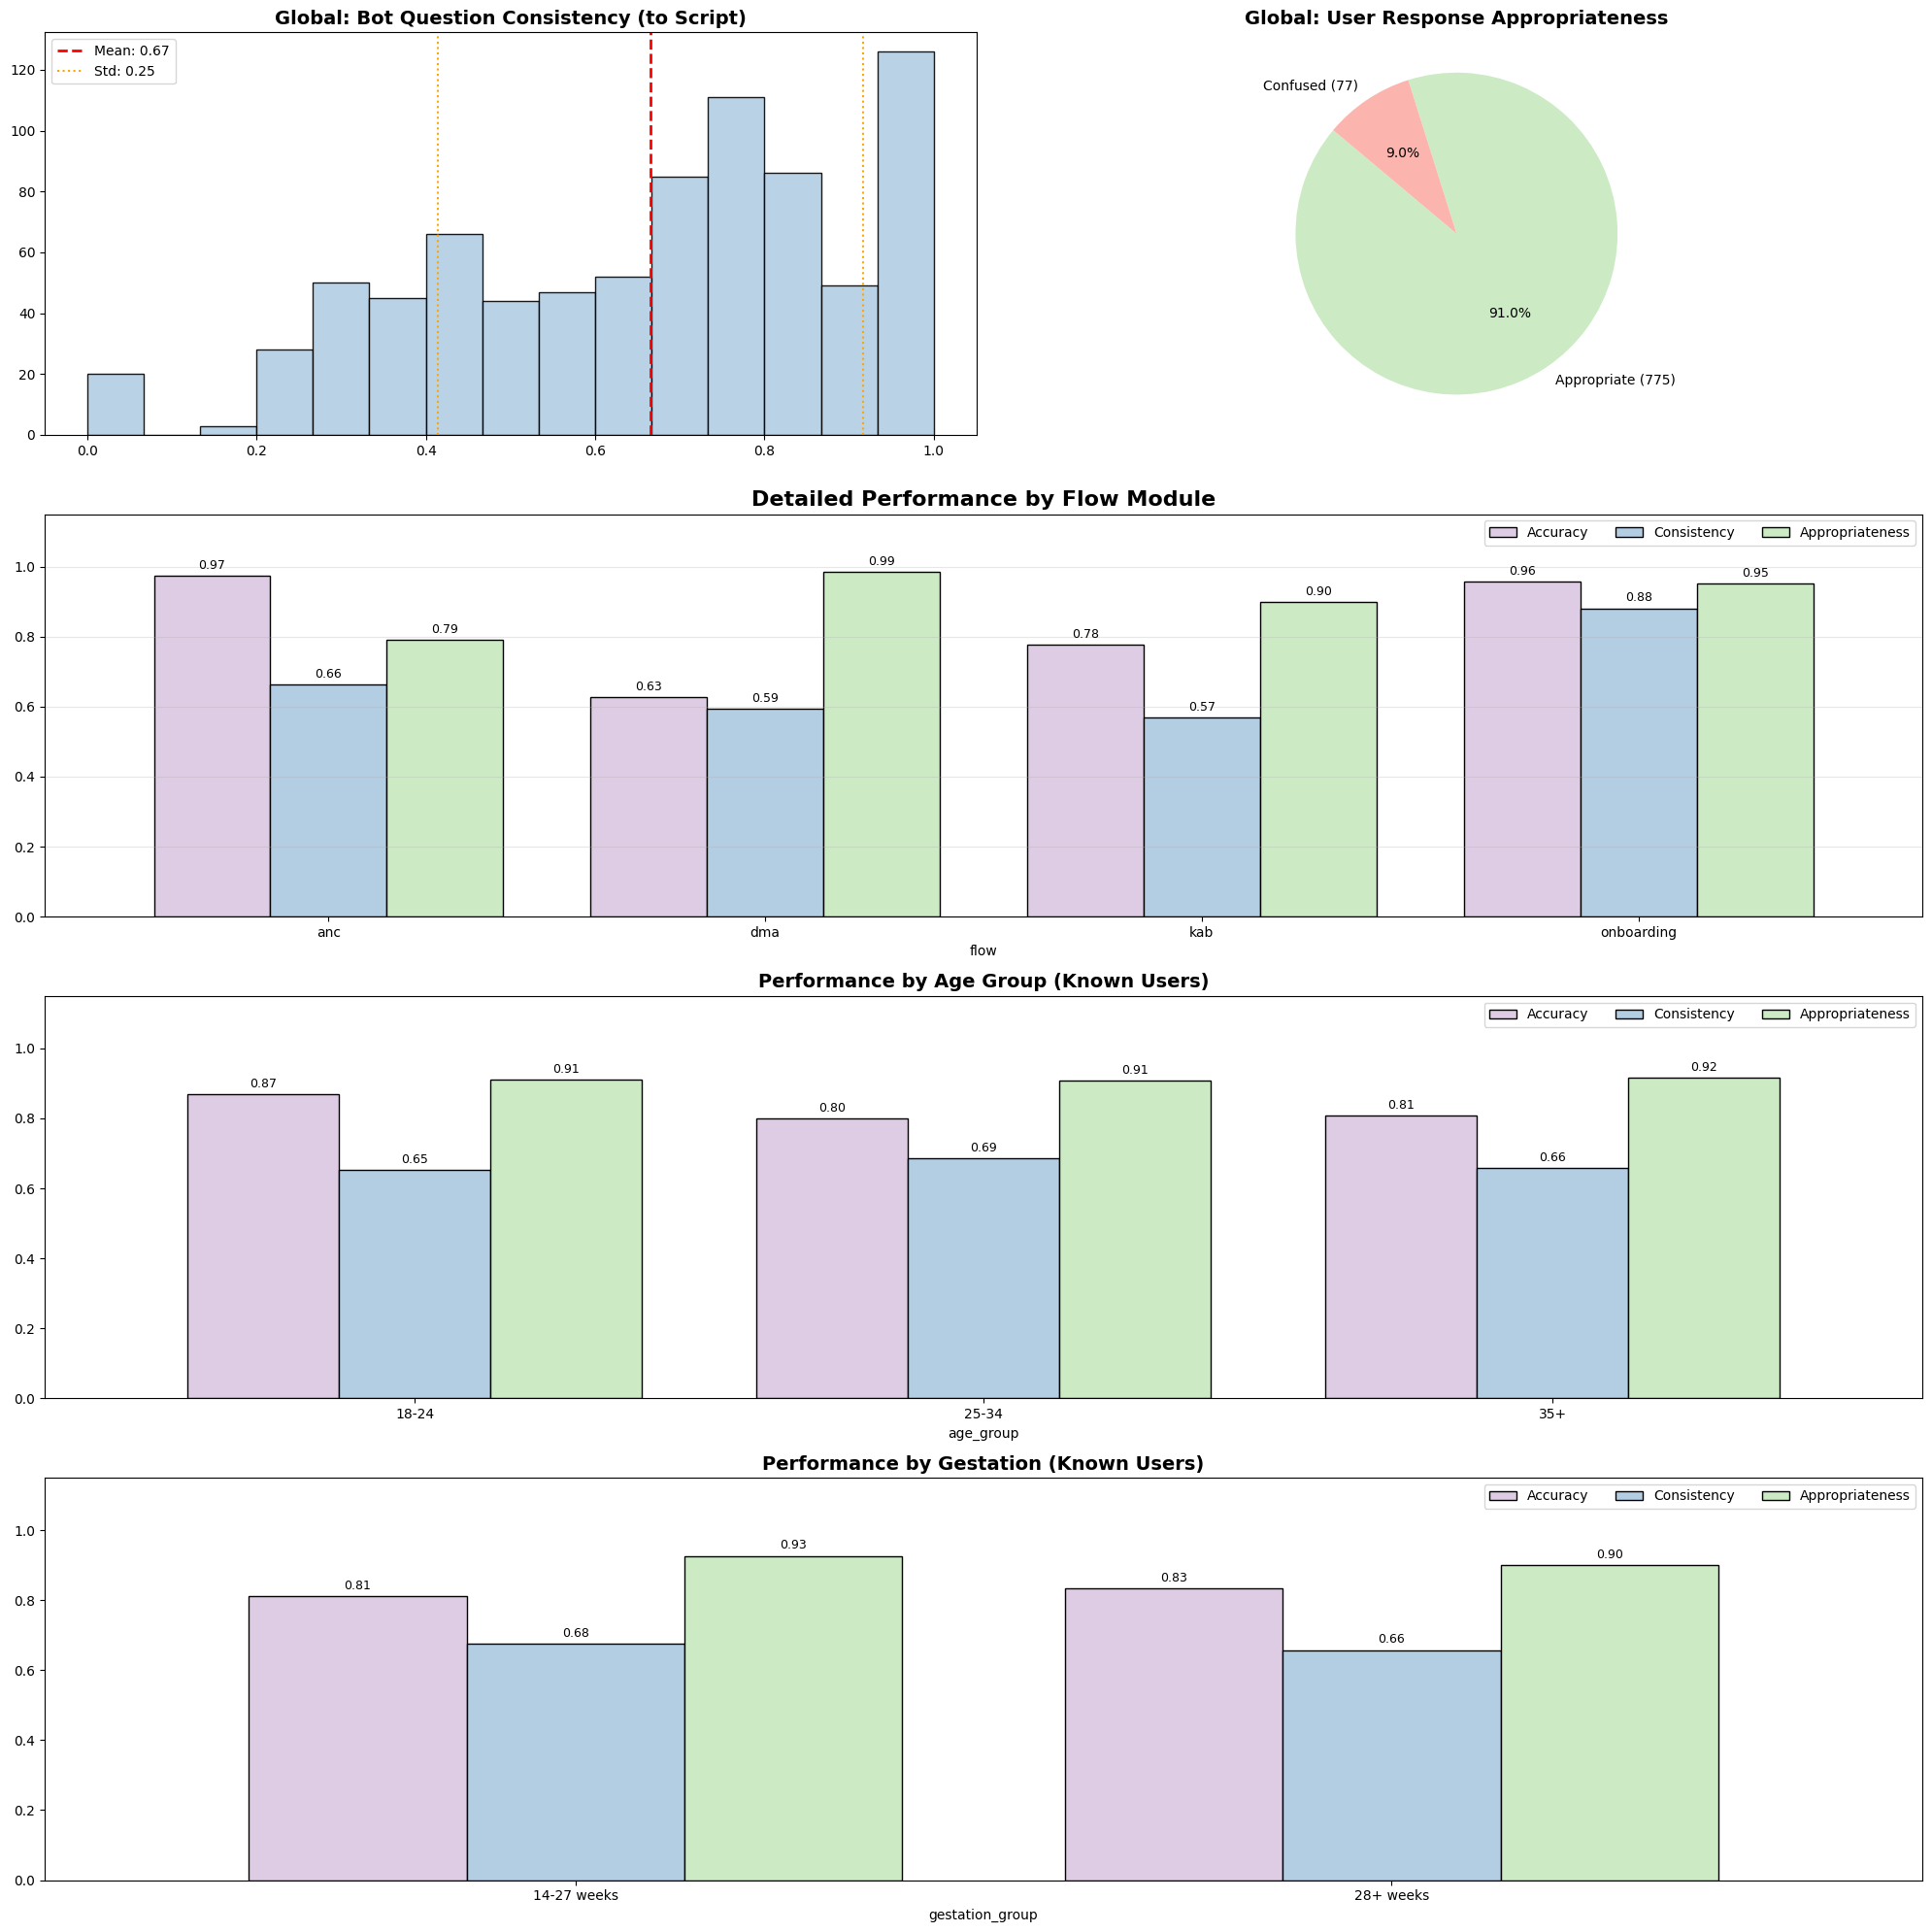

In [4]:
"""
### 3. Pipeline Execution
**Aim:** Runs the full evaluation pipeline:
1. Augment (Map Questions)
2. Evaluate (LLM Judges + Strata Enrichment)
3. Visualize (Matplotlib Plots & Reports)
"""

# ==========================================
# STEP 1: AUGMENT DATA
# ==========================================

def step_1_augment():
    print(f"\n--- STEP 1: AUGMENTING DATA ---")
    try:
        df = pd.read_csv(PROD_FILE)
        if 'question_key' not in df.columns:
            df = pd.read_csv(PROD_FILE, header=1)
    except Exception as e:
        print(f"❌ Error reading CSV: {e}")
        return pd.DataFrame()

    definitions = load_flow_definitions(JSON_DIR)
    df['flow_lower'] = df['flow_group'].astype(str).str.lower()
    df['reference_question'] = df.apply(lambda row: find_reference_question(definitions, row['flow_lower'], row.get('question_key', '')) or "MISSING_REF", axis=1)
    df.drop(columns=['flow_lower'], inplace=True)
    
    df.to_csv(VERIFIED_FILE, index=False)
    print(f"✅ Verified Data Saved: {VERIFIED_FILE}")
    
    return df


# ==========================================
# STEP 2: RUN EVALUATION
# ==========================================

consistency_metric = GEval(
    name="Question Consistency",
    criteria="""
    Determine whether the ACTUAL OUTPUT is an acceptable functional equivalent of the EXPECTED OUTPUT.

    The ACTUAL OUTPUT must request the **same data field**, expect the **same data type**, and preserve the **same intent** as defined in the script.

    PASS CRITERIA (ALL must be true):
    1. **Data Type Match:** The question requires the same type of answer as the script (date vs integer vs category, etc.).
    2. **Information Field Match:** The question targets the exact same structured field (e.g., ANC visit count, Province, Date of Birth).
    3. **Intent Preservation:** The purpose of the question is unchanged.
    4. **Safe Augmentation:** Additional helpful wording, emojis, or contextual explanation is allowed as long as it does not alter the required answer.

    EXAMPLES OF SAFE AUGMENTATION:
    - Adding answer options or clarifying them.
    - Adding context (“And what about this one…”).
    - Minor grammar changes (“should you go to” vs “should you have”).
    - Additional framing or instructions that improve accuracy.

    FAIL CASES (ANY is a fail):
    - **Different Data Field:** Asking for a related but different field 
      (Age vs DOB; Due Date vs Weeks Pregnant; Location vs Province).
    - **Different Data Type:** Changing format requirements or introducing ambiguity.
    - **Constraint Violation:** Replacing a categorical question with an open-ended one when categories are required.
    - **Generalization That Breaks Mapping:** Broad questions that can produce unmappable answers.
    - **Information Drift:** Any shift in meaning that would result in the wrong data being captured.
    """,
    evaluation_params=[LLMTestCaseParams.ACTUAL_OUTPUT, LLMTestCaseParams.EXPECTED_OUTPUT],
    model="gpt-4o"
)

def step_2_evaluate(df, consistency_metric=consistency_metric):
    print(f"\n--- STEP 2: EVALUATION ---")
    
    # LOAD CACHE IF EXISTS
    if not RERUN_EVALUATION and os.path.exists(FINAL_REPORT):
        print(f"ℹ️ Loading cached results from {FINAL_REPORT}...")
        res_df = pd.read_csv(FINAL_REPORT)
        # Re-enrich to ensure strata is up to date
        return enrich_with_strata(res_df, STRATA_FILE, ID_MAP_FILE)

    # INIT METRICS
    print("Initializing LLM Judges (GPT-4o)...")
    relevancy_metric = AnswerRelevancyMetric(threshold=0.7, model="gpt-4o", include_reason=True)

    # FILTER 'OTHER' & SAMPLE
    # Robust case-insensitive filter
    df_clean = df[df['flow_group'].astype(str).str.lower() != 'other'].copy()
    print(f"   > Filtered out 'other' flows. Remaining: {len(df_clean)}")

    if SAMPLE_SIZE:
        print(f"⚠️ TEST MODE: Sampling {SAMPLE_SIZE} rows per Question Key...")
        eval_df = df_clean.groupby(['flow_group', 'question_key']).head(SAMPLE_SIZE).copy()
        eval_df = eval_df.sample(frac=1, random_state=42).reset_index(drop=True)

    else:
        print(f"🚀 FULL MODE: Evaluating {len(df_clean)} rows.")
        eval_df = df_clean.copy()

    results = []
    for idx, row in eval_df.iterrows():
        if idx % 10 == 0: print(f"Processing row {idx}...")
        
        actual_q = str(row.get('llm_question_text', ''))
        ref_q = str(row.get('reference_question', ''))
        user_ans = str(row.get('user_answer_raw', ''))
        sys_map = preprocess_text(row.get('user_answer_mapped', ''))
        human_map = preprocess_text(row.get('user_answer_mapped_by_human', ''))

        if not human_map or human_map in ['nan', 'tba', '']:
            continue

        # Metric 1: Accuracy
        is_accurate = (sys_map == human_map)

        # Metric 2: Consistency
        cons_score, cons_reason = None, "N/A"
        if ref_q not in ["MISSING_REF", "nan", ""]:
            try:
                tc = LLMTestCase(input="Check", actual_output=actual_q, expected_output=ref_q)
                consistency_metric.measure(tc)
                cons_score, cons_reason = consistency_metric.score, consistency_metric.reason
            except:
                pass

        # Metric 3: Appropriateness
        app_score, app_reason = None, "N/A"
        if actual_q and user_ans and user_ans != "nan":
            try:
                tc = LLMTestCase(input=actual_q, actual_output=user_ans)
                relevancy_metric.measure(tc)
                app_score, app_reason = relevancy_metric.score, relevancy_metric.reason
            except:
                pass

        results.append({
            "contact_id": row.get('contact_id'), "flow": row.get('flow_group'), "key": row.get('question_key'),
            "llm_question": actual_q, "ref_question": ref_q, "user_input": user_ans,
            "extraction_correct": is_accurate, "consistency_score": cons_score, "appropriateness_score": app_score,
            "sys_map": sys_map, "human_map": human_map, "consistency_reason": cons_reason, "appropriateness_reason": app_reason
        })

    res_df = pd.DataFrame(results)
    res_df = enrich_with_strata(res_df, STRATA_FILE, ID_MAP_FILE)
    res_df.to_csv(FINAL_REPORT, index=False)
    print(f"✅ Saved results to {FINAL_REPORT}")
    return res_df


# ==========================================
# STEP 3: VISUALIZE (Matplotlib Only)
# ==========================================
def step_3_visualize(res_df):
    if res_df.empty:
        return

    # ==========================================
    # 1. DATA TABLES (Global -> Flow -> Demo -> MERL)
    # ==========================================
    print("\n" + "="*60)
    print(f"📊 EVALUATION REPORT (N={len(res_df)})")
    print("="*60)
    
    # --- A. GLOBAL SUMMARY ---
    print("\n► 1. GLOBAL PERFORMANCE")
    global_metrics = pd.DataFrame({
        'Metric': ['Extraction Accuracy', 'Question Consistency', 'Response Appropriateness'],
        'Score': [
            res_df['extraction_correct'].mean(),
            res_df['consistency_score'].mean(),
            res_df['appropriateness_score'].mean()
        ],
        'Count': [
            res_df['extraction_correct'].count(),
            res_df['consistency_score'].count(),
            res_df['appropriateness_score'].count()
        ]
    })
    # Display Global Table
    display(global_metrics.style.format({'Score': '{:.2%}'}).hide(axis='index'))

    # --- B. FLOW MODULES ---
    print("\n► 2. PERFORMANCE BY FLOW MODULE (Raw Data)")
    flow_stats = res_df.groupby('flow').agg({
        'extraction_correct': 'mean',
        'consistency_score': 'mean',
        'appropriateness_score': 'mean',
        'contact_id': 'count'
    })
    flow_stats.columns = ['Accuracy', 'Consistency', 'Appropriateness', 'Turn Count']
    
    display(flow_stats.style.format({
        'Accuracy': '{:.1%}', 
        'Consistency': '{:.1%}', 
        'Appropriateness': '{:.1%}'
    }).background_gradient(cmap='RdYlGn', vmin=0, vmax=1))

    # --- C. MERL EXPORT TABLE (With Counts) ---
    print("\n► 3. DETAILED EXPORT TABLE (Flow x Age x Gestation)")
    
    if 'age_group' in res_df.columns and 'gestation_group' in res_df.columns:
        # Aggregation with Means and Counts
        merl_base = res_df.groupby(['flow', 'age_group', 'gestation_group'], dropna=False).agg(
            no_users=('contact_id', 'nunique'),
            no_turns=('contact_id', 'count'),
            cons_mean=('consistency_score', 'mean'), cons_count=('consistency_score', 'count'),
            app_mean=('appropriateness_score', 'mean'), app_count=('appropriateness_score', 'count'),
            acc_mean=('extraction_correct', 'mean'), acc_count=('extraction_correct', 'count')
        ).reset_index()

        # Format Columns as "90% (10)"
        def fmt(mean, count):
            if pd.isna(mean): return "N/A"
            return f"{mean:.1%} ({count})"

        merl_display = merl_base.copy()
        merl_display['question_consistency'] = merl_display.apply(lambda x: fmt(x['cons_mean'], x['cons_count']), axis=1)
        merl_display['response_appropriateness'] = merl_display.apply(lambda x: fmt(x['app_mean'], x['app_count']), axis=1)
        merl_display['response_mapping_accuracy'] = merl_display.apply(lambda x: fmt(x['acc_mean'], x['acc_count']), axis=1)

        final_cols = ['flow', 'age_group', 'gestation_group', 'no_users', 'no_turns', 
                      'question_consistency', 'response_appropriateness', 'response_mapping_accuracy']
        
        # Save & Display
        merl_final = merl_display[final_cols]
        merl_final.to_csv("data/detailed_metrics_export.csv", index=False)
        print("✅ Saved detailed table to: data/detailed_metrics_export.csv")
        display(merl_final.style.background_gradient(cmap='Blues', subset=['no_turns']))
    else:
        print("⚠️ Missing demographic columns. MERL table skipped.")

    # --- D. DEMOGRAPHICS ---
    print("\n► 4. PERFORMANCE BY DEMOGRAPHICS")
    
    if 'age_group' in res_df.columns:
        print("\n(Table A) By Age Group:")
        age_stats = res_df.groupby('age_group', dropna=False).agg({
            'extraction_correct': 'mean', 'consistency_score': 'mean', 'appropriateness_score': 'mean', 'contact_id': 'count'
        })
        age_stats.columns = ['Accuracy', 'Consistency', 'Appropriateness', 'Count']
        display(age_stats.style.format({'Accuracy': '{:.1%}', 'Consistency': '{:.1%}', 'Appropriateness': '{:.1%}'}).background_gradient(cmap='Blues'))

    if 'gestation_group' in res_df.columns:
        print("\n(Table B) By Gestation Stage:")
        gest_stats = res_df.groupby('gestation_group', dropna=False).agg({
            'extraction_correct': 'mean', 'consistency_score': 'mean', 'appropriateness_score': 'mean', 'contact_id': 'count'
        })
        gest_stats.columns = ['Accuracy', 'Consistency', 'Appropriateness', 'Count']
        display(gest_stats.style.format({'Accuracy': '{:.1%}', 'Consistency': '{:.1%}', 'Appropriateness': '{:.1%}'}).background_gradient(cmap='Purples'))

    # ==========================================
    # 2. VISUALIZATIONS
    # ==========================================
    print("\n" + "="*60)
    print("📈 VISUALIZATIONS")
    print("="*60)
    
    try: plt.style.use('seaborn-v0_8-pastel') 
    except: pass

    fig = plt.figure(figsize=(20, 20))
    plt.subplots_adjust(hspace=0.5, wspace=0.3)

    # Plot 1: Consistency
    ax1 = plt.subplot(4, 2, 1)
    cons_data = res_df['consistency_score'].dropna()
    if not cons_data.empty:
        mean_val, std_val = cons_data.mean(), cons_data.std()
        ax1.hist(cons_data, bins=15, range=(0,1), color='#b3cde3', edgecolor='black', alpha=0.9)
        ax1.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        ax1.axvline(mean_val - std_val, color='orange', linestyle=':', label=f'Std: {std_val:.2f}')
        ax1.axvline(mean_val + std_val, color='orange', linestyle=':')
        ax1.set_title('Global: Bot Question Consistency (to Script)', fontsize=14, fontweight='bold')
        ax1.legend()
    else: ax1.text(0.5, 0.5, "No Data", ha='center')

    # Plot 2: Appropriateness
    ax2 = plt.subplot(4, 2, 2)
    app_data = res_df['appropriateness_score'].dropna()
    if not app_data.empty:
        good = (app_data >= 0.7).sum()
        bad = (app_data < 0.7).sum()
        ax2.pie([good, bad], labels=[f'Appropriate ({good})', f'Confused ({bad})'], autopct='%1.1f%%', colors=['#ccebc5', '#fbb4ae'], startangle=140)
        ax2.set_title('Global: User Response Appropriateness', fontsize=14, fontweight='bold')
    else: ax2.text(0.5, 0.5, "No Data", ha='center')

    # Plot 3: Flow (With Labels)
    ax3 = plt.subplot(4, 1, 2)
    flow_plot = res_df.groupby('flow')[['extraction_correct', 'consistency_score', 'appropriateness_score']].mean()
    flow_plot.columns = ['Accuracy', 'Consistency', 'Appropriateness']
    
    # Plot grouped bar chart
    flow_plot.plot(kind='bar', ax=ax3, width=0.8, color=['#decbe4', '#b3cde3', '#ccebc5'], edgecolor='black')
    
    # Add Value Labels on Top
    for container in ax3.containers:
        ax3.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

    ax3.set_title('Detailed Performance by Flow Module', fontsize=16, fontweight='bold')
    ax3.set_ylim(0, 1.15)
    ax3.legend(loc='upper right', ncol=3)
    ax3.grid(axis='y', alpha=0.3)
    plt.setp(ax3.get_xticklabels(), rotation=0)

    # Plot 4: Age
    ax4 = plt.subplot(4, 1, 3)
    if 'age_group' in res_df.columns:
        age_clean = res_df[res_df['age_group'] != 'Unknown']
        if not age_clean.empty:
            age_plot = age_clean.groupby('age_group')[['extraction_correct', 'consistency_score', 'appropriateness_score']].mean()
            age_plot.columns = ['Accuracy', 'Consistency', 'Appropriateness']
            age_plot.plot(kind='bar', ax=ax4, width=0.8, color=['#decbe4', '#b3cde3', '#ccebc5'], edgecolor='black')
            ax4.set_title('Performance by Age Group (Known Users)', fontsize=14, fontweight='bold')
            ax4.set_ylim(0, 1.15)
            ax4.legend(loc='upper right', ncol=3)
            # Add Labels
            for container in ax4.containers:
                ax4.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
            plt.setp(ax4.get_xticklabels(), rotation=0)
        else: ax4.text(0.5, 0.5, "No Known Age Data", ha='center')

    # Plot 5: Gestation
    ax5 = plt.subplot(4, 1, 4)
    if 'gestation_group' in res_df.columns:
        gest_clean = res_df[res_df['gestation_group'] != 'Unknown']
        if not gest_clean.empty:
            gest_plot = gest_clean.groupby('gestation_group')[['extraction_correct', 'consistency_score', 'appropriateness_score']].mean()
            gest_plot.columns = ['Accuracy', 'Consistency', 'Appropriateness']
            gest_plot.plot(kind='bar', ax=ax5, width=0.8, color=['#decbe4', '#b3cde3', '#ccebc5'], edgecolor='black')
            ax5.set_title('Performance by Gestation (Known Users)', fontsize=14, fontweight='bold')
            ax5.set_ylim(0, 1.15)
            ax5.legend(loc='upper right', ncol=3)
            # Add Labels
            for container in ax5.containers:
                ax5.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
            plt.setp(ax5.get_xticklabels(), rotation=0)
        else: ax5.text(0.5, 0.5, "No Known Gestation Data", ha='center')

    plt.tight_layout()
    plt.show()


# --- EXECUTE ---
if __name__ == "__main__":
    df_ver = step_1_augment()
    if not df_ver.empty:
        df_res = step_2_evaluate(df_ver)
        step_3_visualize(df_res)


📊 EVALUATION REPORT (N=853)

► 1. GLOBAL PERFORMANCE


Metric,Score,Count
Extraction Accuracy,82.42%,853
Question Consistency,66.52%,823
Response Appropriateness,91.14%,852



► 2. PERFORMANCE BY FLOW MODULE (Raw Data)


,Accuracy,Consistency,Appropriateness,Turn Count
flow,,,,
anc,97.4%,66.3%,79.1%,116
dma,62.7%,59.3%,98.5%,134
kab,77.6%,56.8%,89.9%,393
onboarding,95.7%,88.1%,95.2%,210



► 3. DETAILED EXPORT TABLE (Flow x Age x Gestation)
✅ Saved detailed table to: data/detailed_metrics_export.csv


...


► 4. PERFORMANCE BY DEMOGRAPHICS

(Table A) By Age Group:


,Accuracy,Consistency,Appropriateness,Count
age_group,,,,
18-24,86.8%,65.2%,91.1%,265
25-34,79.9%,68.7%,90.7%,274
35+,80.9%,65.8%,91.6%,314



(Table B) By Gestation Stage:


,Accuracy,Consistency,Appropriateness,Count
gestation_group,,,,
14-27 weeks,81.2%,67.6%,92.6%,367
28+ weeks,83.3%,65.7%,90.0%,486



📈 VISUALIZATIONS


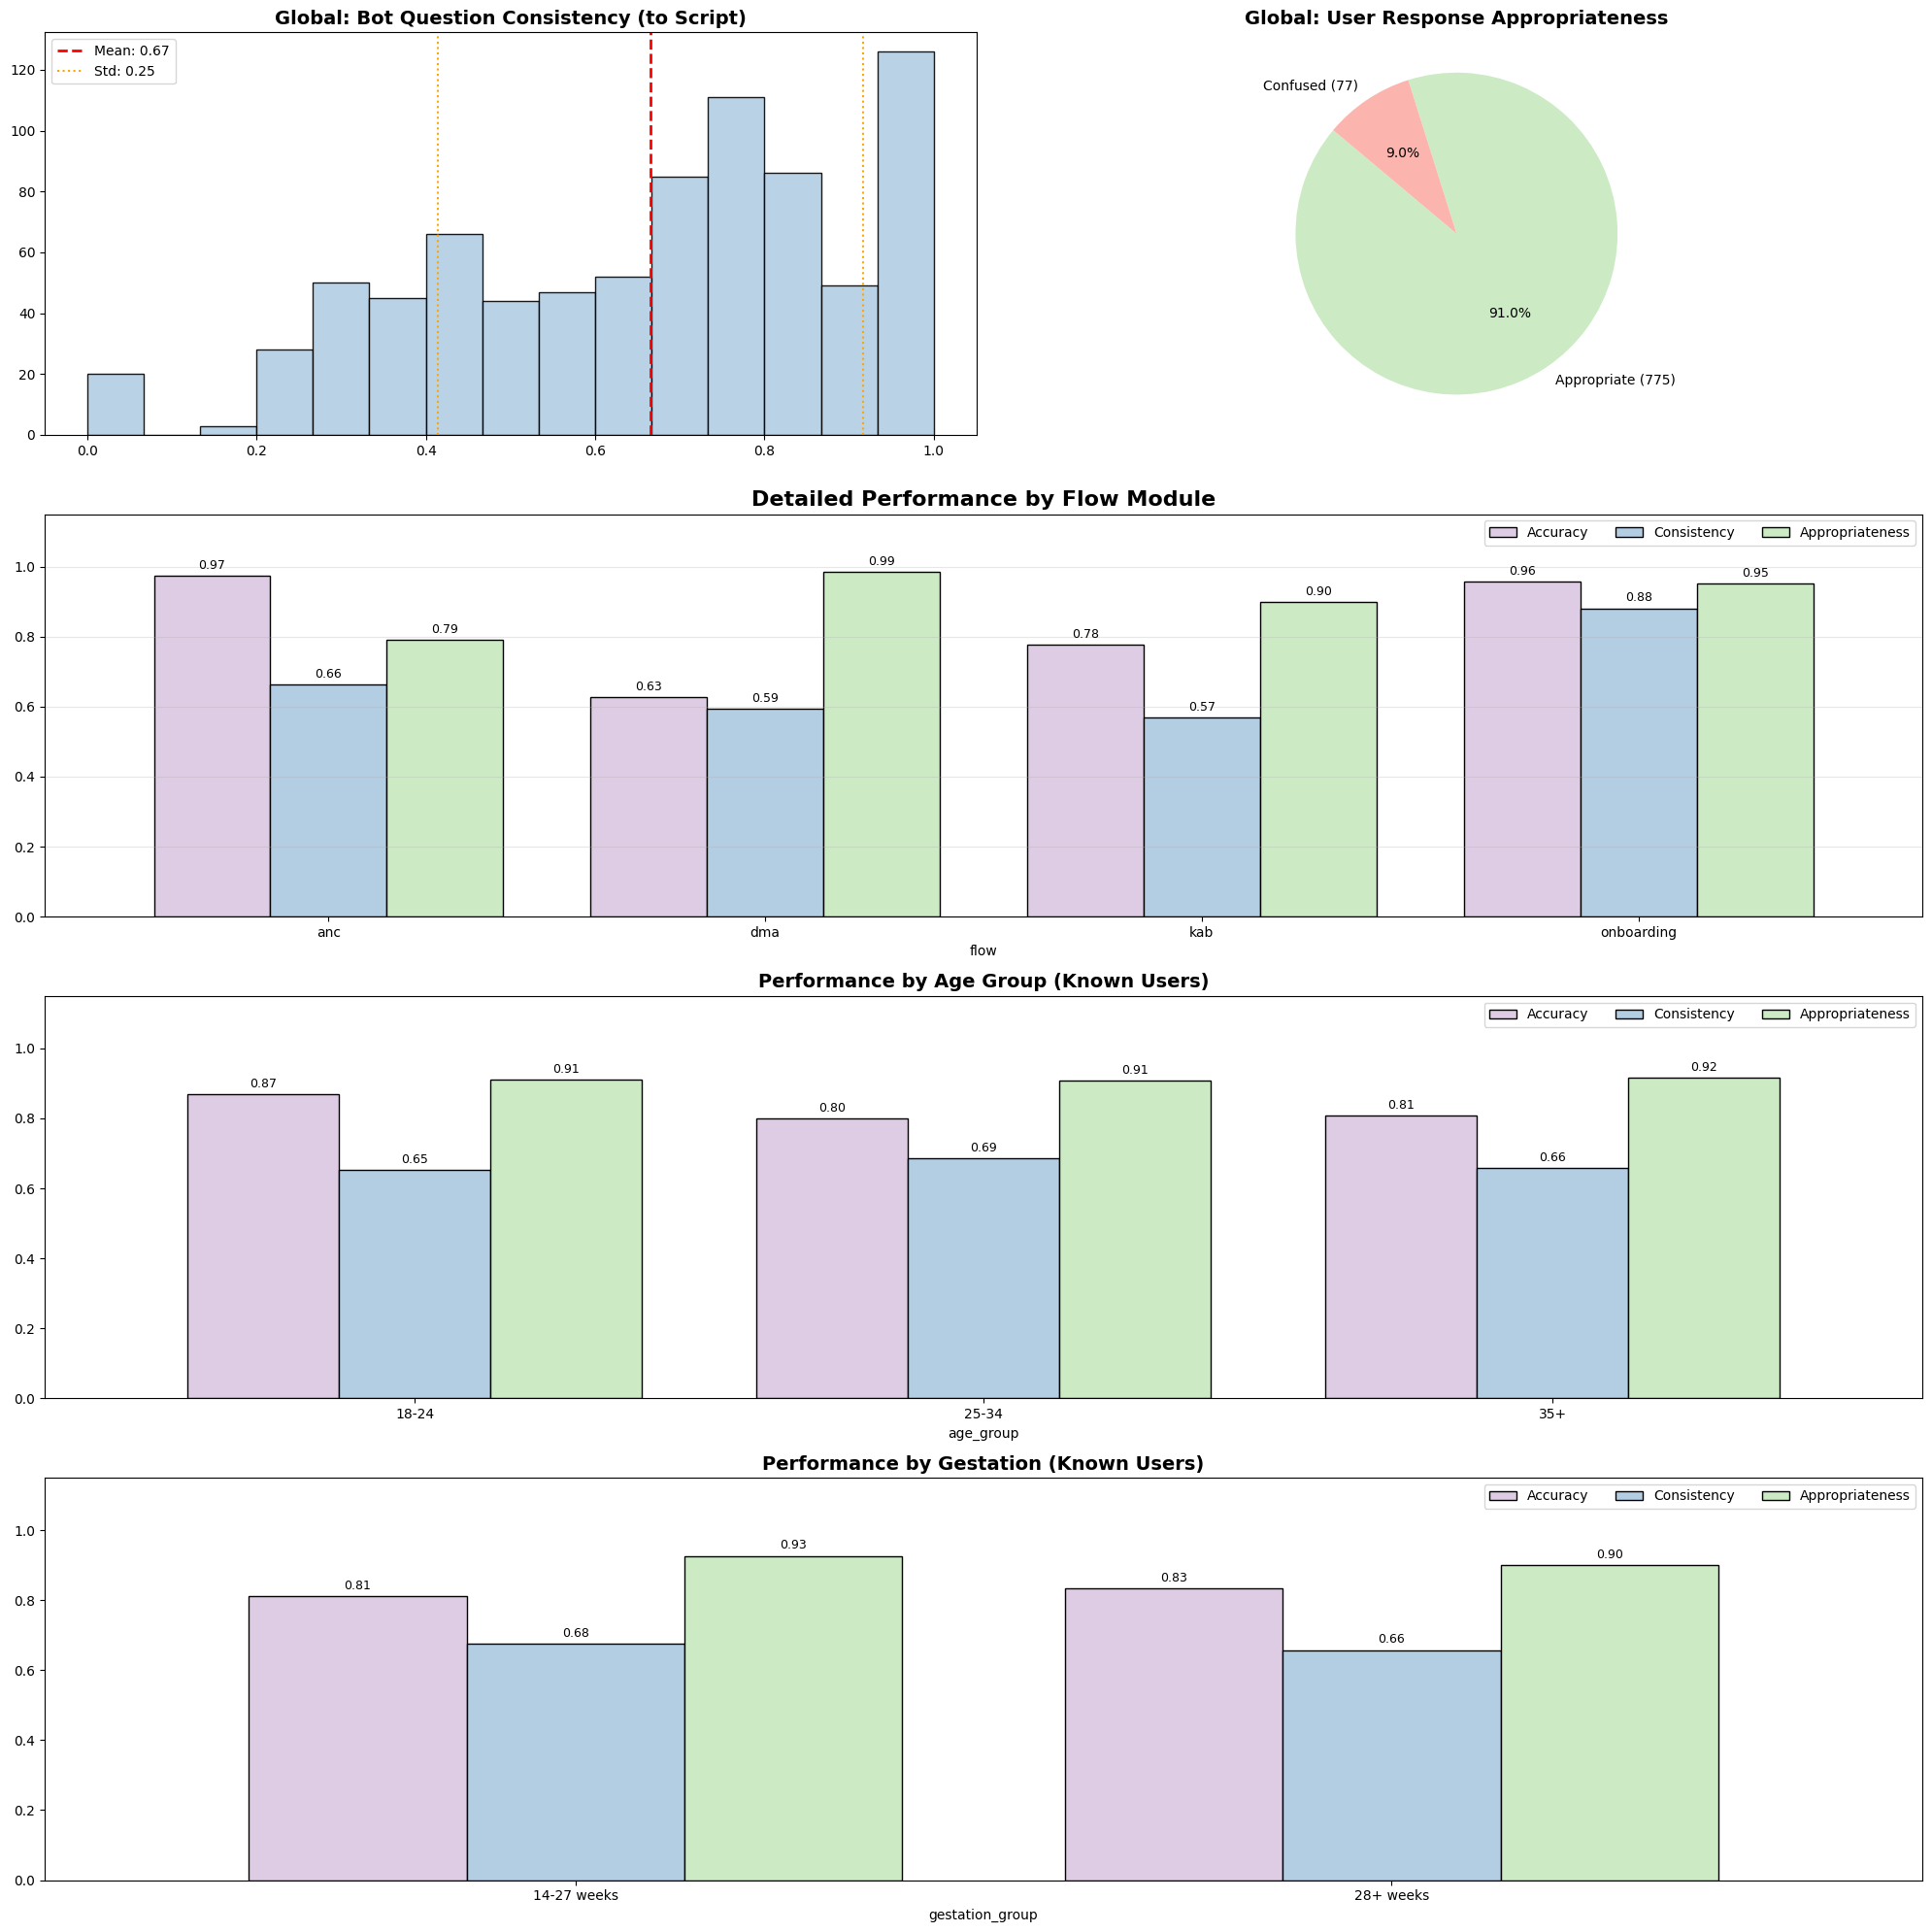

In [6]:
step_3_visualize(df_res)

# Separate: Onboarding Order

# Comment from MERL: run this on the full userbase who did onboarding


⏳ STEP 4: ONBOARDING SEQUENCE & DMA CONVERSION



### 🔍 Step 4: Sequence Analysis (Randomness Proof)

**Goal:** Determine if the order of onboarding questions is **Fixed** (linear) or **Randomized** (dynamic) for each user.

#### **How to Interpret the Results:**

| Indicator | **🔴 Fixed Order** (Control) | **🟢 Randomized Order** (Experiment) |
| :--- | :--- | :--- |
| **Visual Heatmap** | Shows a clear **Diagonal Line** ↘️. <br>*(Q1 is always Step 1, Q2 is always Step 2)* | Shows a **Scattered Grid** 🏁. <br>*(Any question can appear at any step)* |
| **Unique Paths** | **1 Path found.** <br>*(Every user followed the exact same sequence)* | **Multiple Paths found.** <br>*(Users experienced different sequences)* |

---
**Key Finding:**
* If `Unique Paths > 1`, the system is correctly randomizing the flow.
* If `Unique Paths == 1`, the system is serving a static flow.
    


► VISUAL PROOF: Question Distribution by Step


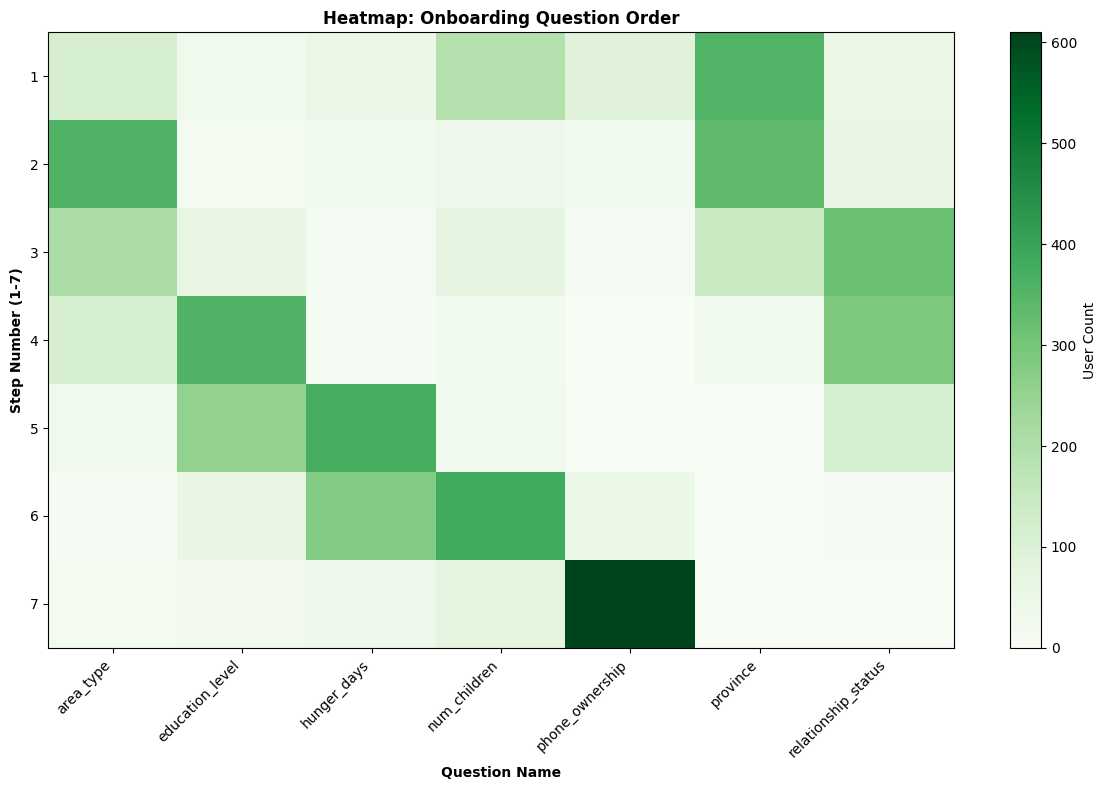


► DATA PROOF: Top Sequences & DMA Metrics
✅ Saved FULL sequence analysis to: data/onboarding_sequencing.csv
Total Onboarding Users: 878
Unique Paths: 195
✅ RESULT: The order is randomized.

Top 5 User Journeys:


,Full Sequence Order,Users,Started DMA,DMA Completion Rate
1,province → area_type → relationship_status → education_level → hunger_days → num_children → phone_ownership,185,173,82.2% (152)
2,area_type → province → relationship_status → education_level → hunger_days → num_children → phone_ownership,54,52,87.0% (47)
3,num_children → province → area_type → relationship_status → education_level → hunger_days → phone_ownership,45,43,88.9% (40)
4,phone_ownership → province → area_type → relationship_status → education_level → hunger_days → num_children,39,38,74.4% (29)
5,province → area_type → education_level → relationship_status → hunger_days → num_children → phone_ownership,32,30,81.2% (26)


In [5]:
from IPython.display import Markdown, display

def step_4_randomness_proof():
    print("\n" + "="*60)
    print("⏳ STEP 4: ONBOARDING SEQUENCE & DMA CONVERSION")
    print("="*60)
    
    
    # --- 1. DISPLAY INTERPRETATION GUIDE FIRST ---
    display(Markdown("""
### 🔍 Step 4: Sequence Analysis (Randomness Proof)

**Goal:** Determine if the order of onboarding questions is **Fixed** (linear) or **Randomized** (dynamic) for each user.

#### **How to Interpret the Results:**

| Indicator | **🔴 Fixed Order** (Control) | **🟢 Randomized Order** (Experiment) |
| :--- | :--- | :--- |
| **Visual Heatmap** | Shows a clear **Diagonal Line** ↘️. <br>*(Q1 is always Step 1, Q2 is always Step 2)* | Shows a **Scattered Grid** 🏁. <br>*(Any question can appear at any step)* |
| **Unique Paths** | **1 Path found.** <br>*(Every user followed the exact same sequence)* | **Multiple Paths found.** <br>*(Users experienced different sequences)* |

---
**Key Finding:**
* If `Unique Paths > 1`, the system is correctly randomizing the flow.
* If `Unique Paths == 1`, the system is serving a static flow.
    """))

    # --- 2. LOAD & PROCESS DATA ---
    try:
        df_all = pd.read_csv('data/all_onboarding_user_turns.csv')
    except Exception as e: 
        print(f"❌ Could not read file: {e}")
        return

    # Identify cohorts
    dma_starters = set(df_all[df_all['flow_group'].astype(str).str.lower().str.contains('dma', na=False)]['contact_id'].unique())
    DMA_FINAL_KEY = 'dma-pre-assessment-5'
    dma_completers = set(df_all[df_all['question_key'] == DMA_FINAL_KEY]['contact_id'].unique())

    # Filter Onboarding
    df = df_all[df_all['flow_group'].astype(str).str.lower() == 'onboarding'].copy()
    
    # Determine Order
    if 'question_ts' in df.columns:
        df['ts'] = pd.to_datetime(df['question_ts'], errors='coerce')
    elif 'answer_ts' in df.columns:
        df['ts'] = pd.to_datetime(df['answer_ts'], errors='coerce')
    else:
        print("❌ No timestamps found.")
        return

    df = df.sort_values(['contact_id', 'ts'])
    df = df.drop_duplicates(subset=['contact_id', 'question_key'], keep='first')
    df['step_number'] = df.groupby('contact_id').cumcount() + 1

    # --- 3. VISUAL HEATMAP ---
    print("\n► VISUAL PROOF: Question Distribution by Step")
    pivot_counts = pd.crosstab(df['step_number'], df['question_key'])
    
    plt.figure(figsize=(12, 8))
    plt.imshow(pivot_counts, cmap='Greens', aspect='auto')
    plt.colorbar(label='User Count')
    plt.xticks(range(len(pivot_counts.columns)), pivot_counts.columns, rotation=45, ha='right')
    plt.yticks(range(len(pivot_counts.index)), pivot_counts.index)
    plt.ylabel('Step Number (1-7)', fontweight='bold')
    plt.xlabel('Question Name', fontweight='bold')
    plt.title('Heatmap: Onboarding Question Order', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- 4. SEQUENCE DATA ---
    print("\n► DATA PROOF: Top Sequences & DMA Metrics")
    
    sequences = df.groupby('contact_id')['question_key'].agg(
        lambda x: ' → '.join(x.astype(str))
    ).reset_index(name='path')
    
    sequences['started_dma'] = sequences['contact_id'].isin(dma_starters)
    sequences['completed_dma'] = sequences['contact_id'].isin(dma_completers)
    
    path_stats = sequences.groupby('path').agg(
        User_Count=('contact_id', 'count'),
        DMA_Start_Count=('started_dma', 'sum'),
        DMA_Complete_Count=('completed_dma', 'sum')
    ).reset_index()
    
    path_stats['completion_rate_val'] = path_stats['DMA_Complete_Count'] / path_stats['User_Count']
    
    path_stats['DMA Completion Rate'] = path_stats.apply(
        lambda row: f"{row['completion_rate_val']:.1%} ({row['DMA_Complete_Count']})", axis=1
    )
    
    path_stats = path_stats.sort_values('User_Count', ascending=False)
    
    # Save Full CSV
    csv_output = path_stats.copy()
    csv_output.columns = ['Sequence', 'Users_Onboarding', 'Users_Started_DMA', 'Users_Completed_DMA', 'DMA_Completion_Rate_Raw', 'DMA_Completion_Rate_Fmt']
    csv_output.to_csv('data/onboarding_sequencing.csv', index=False)
    print("✅ Saved FULL sequence analysis to: data/onboarding_sequencing.csv")

    # Format for Display
    path_stats_display = path_stats[['path', 'User_Count', 'DMA_Start_Count', 'DMA Completion Rate']].copy()
    path_stats_display.columns = ['Full Sequence Order', 'Users', 'Started DMA', 'DMA Completion Rate']
    path_stats_display = path_stats_display.reset_index(drop=True)
    path_stats_display.index += 1 
    
    unique_paths = len(path_stats)
    total_users = len(sequences)
    
    print(f"Total Onboarding Users: {total_users}")
    print(f"Unique Paths: {unique_paths}")
    
    if unique_paths > 1:
        print("✅ RESULT: The order is randomized.")
    else:
        print("⚠️ RESULT: The order is fixed.")

    print("\nTop 5 User Journeys:")
    with pd.option_context('display.max_colwidth', None):
        display(
            path_stats_display.head(5).style
            .bar(subset=['Users', 'Started DMA'], color=['#5fba7d', '#4c72b0'], align='left')
        )

step_4_randomness_proof()

### 🔍 Step 4: Sequence Analysis (Randomness Proof)

**Goal:** Determine if the order of onboarding questions is **Fixed** (linear) or **Randomized** (dynamic) for each user.

#### **How to Interpret the Results:**

| Indicator | **🔴 Fixed Order** (Control) | **🟢 Randomized Order** (Experiment) |
| :--- | :--- | :--- |
| **Visual Heatmap** | Shows a clear **Diagonal Line** ↘️. <br>*(Q1 is always Step 1, Q2 is always Step 2)* | Shows a **Scattered Grid** 🏁. <br>*(Any question can appear at any step)* |
| **Unique Paths** | **1 Path found.** <br>*(Every user followed the exact same sequence)* | **Multiple Paths found.** <br>*(Users experienced different sequences)* |

---
**Key Finding:**
* If `Unique Paths > 1`, the system is correctly randomizing the flow.
* If `Unique Paths == 1`, the system is serving a static flow.